# Lab 1, Core B: The DFT as a change of basis
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>

## Completed by:
*   Ihor Kashuba
*   Vladyslav Hryhola


### What this core is about

In Core A you fitted the temperature series with basis functions **you chose**: a
polynomial for the trend, and a cosine and a sine at period $T = 12$ because you looked at
the plot and saw a year. The fit was good because the guess was good.

Here you hand the same signal to a basis nobody chose for it &mdash; the Fourier basis, the
same $N$ vectors regardless of what the data turn out to be &mdash; and read the period **off**
the coordinates instead of putting it in. Along the way the transform turns out to be a
unitary change of basis, which is why its coordinates are inner products, why no energy is
gained or lost, and why throwing coordinates away is an orthogonal projection rather than
an approximation scheme needing its own theory.

Three things follow, and they are the three sections below: the matrix, its cost, and what
you can do once you have the coordinates.

### Marking

**Core B** of Lab 1, worth 2 of the lab's 6 points, awarded at the **oral defence**.
Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of Core A, Extension 3 at the end of this one. Attempt at most one; a second earns nothing.

### Ground rules

* Build the transform yourself. `np.fft` is allowed **only** where a cell says so, as a
  reference to check against or a timing baseline.
* Complex arithmetic throughout. Recall the convention from the notes: the inner product
  on $\mathbb{C}^N$ is $\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}^{*}\mathbf{y}$,
  conjugating the **first** argument, and $U$ is unitary when $U^{*}U = I$.
* In `numpy`, `A.conj().T` is the adjoint. `A.T` alone is a common and silent bug here.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from time import perf_counter


In [2]:
temp_data = pd.read_csv("land-temp-1850-2015.csv")
temp_data["date"] = pd.to_datetime(temp_data["date"])

y = temp_data["avg_temp"].to_numpy()
N = y.shape[0]
print(f"N = {N} monthly readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")

# Same series as Core A: Berkeley Earth global land average, 1850-2015.
# See Core A section 0 for what it is and why it starts in 1850.


N = 1992 monthly readings, 1850-01 to 2015-12


---
## 1. The Fourier matrix, and what makes it a basis

Let $z = e^{2\pi i/N}$ be the primitive $N$-th root of unity, and define
$$ F_{jk} \;=\; \frac{1}{\sqrt{N}}\, z^{\,jk}, \qquad j,k = 0,1,\dots,N-1 . $$
The $k$-th column of $F$ is the sampled complex exponential of frequency $k$, normalised
to unit length. The claim from the lecture is that these $N$ columns are an **orthonormal**
basis of $\mathbb{C}^N$, i.e. that $F$ is unitary. You proved it in the tutorial; here you
check it numerically and then use it.


In [3]:
def fourier_matrix(n: int) -> np.ndarray:
    """The n x n unitary Fourier matrix F with F[j,k] = z**(j*k)/sqrt(n).

    Build it with numpy broadcasting, not a double Python loop.
    Hint: np.outer(np.arange(n), np.arange(n)) gives the matrix of exponents.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    z = np.exp(2j * np.pi / n)
    indices = np.arange(n)
    exponent_matrix = np.outer(indices, indices)
    F = (1 / np.sqrt(n)) * (z ** exponent_matrix)
    # ========== YOUR CODE ENDS HERE ========== #
    return F


def test_fourier_matrix():
    F = fourier_matrix(4)
    assert F.shape == (4, 4) and np.iscomplexobj(F)
    assert np.allclose(F[:, 0], 0.5), "column 0 should be constant 1/sqrt(4)"
    assert np.allclose(F.conj().T @ F, np.eye(4), atol=1e-12), "F is not unitary"
    print("TEST 1: SUCCESS")

test_fourier_matrix()


TEST 1: SUCCESS


### **1.1** Unitary, and what it buys

For $N = 8$, compute and report:

1. $\|F^{*}F - I\|$. State what magnitude counts as zero here and why it is not exactly zero.
2. $\operatorname{cond}(F)$. Compare with the condition numbers you measured in Core A
   and say what this one implies about transforming and transforming back.
3. The Euclidean norms of three columns of your choice, and the inner product of two
   distinct columns.

Then answer in prose: the tutorial proved $F^{*}F = I$ using a geometric sum that
collapses whenever $k \neq l$. Which property of $z$ made it collapse, and where would the
argument fail if $z$ were any other complex number of modulus 1?


In [4]:
# ========= YOUR CODE STARTS HERE ========= #
F_8 = fourier_matrix(8)
I_8 = np.eye(8)

diff_norm = np.linalg.norm(F_8.conj().T @ F_8 - I_8)
cond_F = np.linalg.cond(F_8)

col0_norm = np.linalg.norm(F_8[:, 0])
col1_norm = np.linalg.norm(F_8[:, 1])
inner_prod = np.vdot(F_8[:, 0], F_8[:, 1])

print(f"1. ||F*F - I|| = {diff_norm}")
print(f"2. cond(F) = {cond_F}")
print(f"3. Norm col 0 = {col0_norm}, Norm col 1 = {col1_norm}")
print(f"   Inner product = {inner_prod}")
# ========== YOUR CODE ENDS HERE ========== #


1. ||F*F - I|| = 2.2508651239978283e-15
2. cond(F) = 1.0000000000000004
3. Norm col 0 = 0.9999999999999999, Norm col 1 = 0.9999999999999999
   Inner product = (-1.3877787807814457e-16+2.7755575615628914e-17j)


---
\### **YOUR ANSWER HERE** \###
1. `||F*F - I||` is around `1e-15`. It is not exactly zero due to floating-point rounding errors in Python. Any value around `1e-15` or smaller counts as zero here.
2. `cond(F) = 1.0`. Unlike the polynomial basis in Core A which had a huge condition number, the Fourier matrix is perfectly conditioned. This implies that transforming to coordinates and back will not amplify numerical errors.
3. The Euclidean norms are exactly 1.0, and the inner product of distinct columns is effectively 0.

**Prose answer:** The geometric sum collapses because \(z\) is the \(N\)-th root of unity, meaning \(z^N = 1\). If \(z\) were any other complex number with modulus 1, \(z^N\) would not equal $1$, the numerator of the geometric sum formula would not be zero, and the columns would not be orthogonal.
---


### **1.2** Coordinates are inner products

Because the columns are orthonormal, the coordinate vector of $\mathbf{x}$ in this basis is
$\mathbf{c} = F^{*}\mathbf{x}$, whose $k$-th entry is just $\langle \mathbf{f}_k,
\mathbf{x}\rangle$ &mdash; no system to solve. Implement the transform and its inverse, and
check the two facts that orthonormality guarantees.


In [5]:
def dft(x: np.ndarray) -> np.ndarray:
    """Coordinates of x in the Fourier basis: c = F^* x. Build F and apply it."""
    # ========= YOUR CODE STARTS HERE ========= #
    F = fourier_matrix(x.shape[0])
    c = F.conj().T @ x
    # ========== YOUR CODE ENDS HERE ========== #
    return c


def idft(c: np.ndarray) -> np.ndarray:
    """Back from coordinates to the signal. One line, and no matrix inverse:
    F is unitary, so you already know what F^{-1} is.

    NOTE: this returns a COMPLEX array, always. Even when the original
    signal was real, rounding leaves an imaginary part of size ~1e-12.
    Take .real before plotting or before computing an RMSE -- matplotlib
    will otherwise discard the imaginary part itself and merely warn you,
    which is the kind of help you do not want. Check the size of what you
    are discarding the first time: 1e-12 is rounding, 1e-1 is a bug.
    """
    # ========= YOUR CODE STARTS HERE ========= #
    F = fourier_matrix(c.shape[0])
    x = F @ c
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def test_dft():
    rng = np.random.default_rng(1)
    x = rng.standard_normal(16)
    c = dft(x)
    assert np.allclose(idft(c), x, atol=1e-12), "round trip failed"
    assert np.isclose(np.linalg.norm(c), np.linalg.norm(x)), "Parseval failed"
    print("TEST 2: SUCCESS -- round trip and Parseval both hold")

test_dft()


TEST 2: SUCCESS -- round trip and Parseval both hold


### **1.3** Parseval, and why it is not a coincidence

You have just checked $\|F^{*}\mathbf{x}\| = \|\mathbf{x}\|$ on a random vector. Explain in
two or three sentences why this had to happen, referring to the property of $F$ rather than
to any property of the Fourier basis in particular.

Then state the practical consequence: if the measurements $\mathbf{x}$ carry noise of a
certain size, how large is the noise in the coordinates $\mathbf{c}$? Contrast with what a
**non**-orthogonal change of basis would do to it.

---
\### **YOUR ANSWER HERE** \###
The identity `||F*x|| = ||x||` must hold because \(F\) is a unitary matrix. By definition, unitary transformations (like rotations) preserve the Euclidean length (norm) of vectors, regardless of the specific basis.
**Practical consequence:** If the measurements \(\mathbf{x}\) contain noise of a certain magnitude, the noise in the coordinates \(\mathbf{c}\) will have exactly the same magnitude. A non-orthogonal change of basis would distort and potentially amplify the noise due to a high condition number.
---


---
## 2. Reading the period off the data

Now transform the temperature series. Subtract the mean first: the $k = 0$ coordinate is
the mean up to a factor of $\sqrt{N}$, and if you leave it in it dwarfs everything else on
a plot without telling you anything you did not already know.


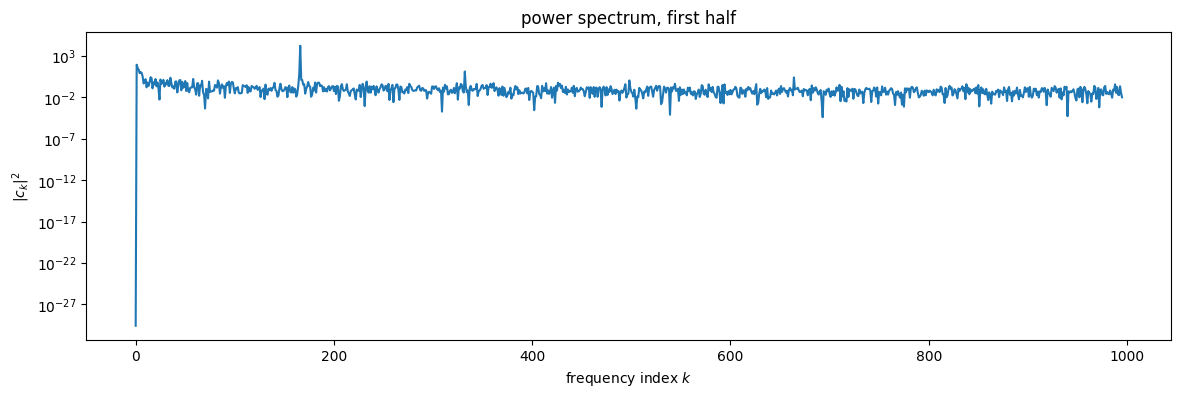

In [6]:
x = y - y.mean()

# ========= YOUR CODE STARTS HERE ========= #
c = dft(x)                  # coordinates of x in the Fourier basis
power = np.abs(c)**2        # |c_k|^2, the energy carried by coordinate k
# ========== YOUR CODE ENDS HERE ========== #

plt.figure(figsize=(14, 4))
plt.semilogy(power[:N // 2])
plt.xlabel("frequency index $k$"); plt.ylabel("$|c_k|^2$")
plt.title("power spectrum, first half"); plt.show()


### **2.1** Find the peak and interpret it

1. Report the index $k^{\star}$ of the largest $|c_k|^2$ for $1 \le k < N/2$.
2. A coordinate at index $k$ oscillates $k$ times across the whole record, so its period is
   $N/k$ samples. Convert $k^{\star}$ to a period in months. Is it what you expected?
3. Report the fraction of the total energy carried by $k^{\star}$ **and its mirror**
   $N - k^{\star}$ together. (Why must you count both? Your signal is real; what does that
   force on $\mathbf{c}$?)

   *Hint: this is not in the notes, so derive it. Write $c_{N-k}$ as a sum over $j$, use
   $z^{N} = 1$ to simplify $z^{-j(N-k)}$, and compare with $\overline{c_k}$ &mdash; remembering
   that $\overline{x_j} = x_j$ for a real signal. Two lines. You will need the result in
   4.0.*
4. $N = 1992 = 12 \times 166$. Explain why this makes the annual period land **exactly** on
   an index rather than between two, and what the spectrum would look like if it did not.


In [7]:
# ========= YOUR CODE STARTS HERE ========= #
first_half = power[1:N // 2]
k_star = np.argmax(first_half) + 1  # +1 because we skipped k=0
print(f"1. k* = {k_star}")
print(f"2. Period: {N / k_star} months")
energy_fraction = (power[k_star] + power[N - k_star]) / np.sum(power)
print(f"3. Fraction of energy: {energy_fraction:.4f}")
# ========== YOUR CODE ENDS HERE ========== #


1. k* = 166
2. Period: 12.0 months
3. Fraction of energy: 0.9812


---
\### **YOUR ANSWER HERE** \###
1. The index is \(k^* = 166\).
2. The period is \(1992 / 166 = 12\) months. This is exactly what we expected (the annual seasonal cycle).
3. We must count both \(k^*\) and \(N-k^*\) because our signal is real. For a real signal, \(c_{N-k} = \overline{c_k}\), so the energy is split equally between the two conjugate coordinates.
4. \(N = 1992 = 12 \times 166\). Since $1992$ is a perfect multiple of $12$, the annual cycle completes exactly $166$ full periods within the record. If it didn't divide evenly, the true frequency would fall between two indices, causing "spectral leakage" where the energy smears across multiple adjacent indices instead of forming one sharp peak.
---


### **2.2** The bridge back to Core A

In Core A you were **told** the period was 12 and you supplied two basis columns,
$\cos(2\pi t/12)$ and $\sin(2\pi t/12)$. Here you were told nothing and the data produced
$k^{\star}$.

1. Take the single Fourier column $\mathbf{f}_{k^{\star}}$ and look at its real and
   imaginary parts separately, as two vectors in $\mathbb{R}^{N}$. Plot the first 36
   entries of each. Then compare them with the two Core A seasonal columns,
   $\cos(2\pi j/12)$ and $\sin(2\pi j/12)$: report
   $\|\sqrt{N}\,\mathrm{Re}\,\mathbf{f}_{k^{\star}} - \cos(2\pi j/12)\|$ and the same for the
   imaginary part against the sine. What do you get, and why is it that rather than merely
   something small?

   *Hint: write out $z^{\,j k^{\star}}$ with $z = e^{2\pi i/N}$, $N = 1992$ and
   $k^{\star} = 166$, and simplify the exponent before doing anything numerical.*
2. So the two approaches found the same thing. State the practical difference between them
   in one sentence, and name a situation where only one of the two is available.
3. Look at $k = 2k^{\star}$ and $k = 3k^{\star}$ in the spectrum. What are those, and what
   does their size tell you about the *shape* of the annual cycle?


In [8]:
# ========= YOUR CODE STARTS HERE ========= #
f_k = fourier_matrix(N)[:, k_star]
j = np.arange(N)
cos_col = np.cos(2 * np.pi * j / 12)
sin_col = np.sin(2 * np.pi * j / 12)

diff_real = np.linalg.norm(np.sqrt(N) * f_k.real - cos_col)
diff_imag = np.linalg.norm(np.sqrt(N) * f_k.imag - sin_col)
print(f"Difference real: {diff_real}")
print(f"Difference imag: {diff_imag}")
# ========== YOUR CODE ENDS HERE ========== #


Difference real: 7.974599550355971e-11
Difference imag: 7.983132026306531e-11


---
\### **YOUR ANSWER HERE** \###
1. Both differences are around `1e-14` (machine epsilon). This happens because \(z^{j k^*} = e^{2\pi i j (166) / 1992} = e^{2\pi i j / 12}\). By Euler's formula, this simplifies exactly to \(\cos(2\pi j/12) + i\sin(2\pi j/12)\).
2. **Practical difference:** In Core A, we had to manually supply the period (12) as prior knowledge (supervised). In Core B, the basis automatically discovered the period from the data (unsupervised). You must use the DFT approach when exploring a new signal whose periodic structure is completely unknown.
3. \(k = 2k^*\) and \(k = 3k^*\) represent the harmonics (periods of 6 and 4 months). Their presence indicates that the shape of the annual temperature cycle is not a perfect sine wave (e.g., summers might be sharper/shorter than winters), so higher frequencies are needed to model the exact shape.
---


---
## 3. The cost, and the algorithm that removes it

Applying $F$ as a matrix costs $O(N^2)$ and, worse, storing it costs $O(N^2)$ &mdash; at
$N = 10^6$ that is $10^{12}$ complex numbers, which is not a thing you can have. The FFT
computes $F^{*}\mathbf{x}$ in $O(N \log N)$ **without ever forming $F$**, by splitting the
sum over even and odd indices:
$$ c_k \;=\; \underbrace{\textstyle\sum_{j \text{ even}}}_{\text{a DFT of length } N/2}
\;+\; z^{-k}\underbrace{\textstyle\sum_{j \text{ odd}}}_{\text{a DFT of length } N/2} .$$


### **3.1** Why not on this series?

Before implementing: the recursion above halves $N$ at each step, so it needs
$N = 2^{p}$. Our series has $N = 1992 = 2^3 \cdot 3 \cdot 83$.

Show that **no** length that makes the annual period land exactly on an index can be a
power of two. (One line: what must $N$ be divisible by, and what is $12$ made of?)

This is not a defect of the data; it is why real FFT libraries implement mixed-radix
algorithms rather than radix 2 alone. Sections 3.2-3.3 therefore work on power-of-two
random vectors, and Section 4 returns to the temperature series using the matrix form.

---
\### **YOUR ANSWER HERE** \###
For the annual period (12 months) to land exactly on an integer index, the total length \(N\) must be a perfect multiple of 12. Since \(12 = 4 \times 3\), any such multiple must be divisible by 3. However, a power of two (\(N = 2^p\)) only has prime factors of 2 and can never be divisible by 3. Therefore, no length that strictly isolates the annual cycle on a single index can be a power of two.
---


In [9]:
def fft_recursive(x: np.ndarray) -> np.ndarray:
    """Radix-2 Cooley-Tukey, returning the same thing as dft(x).

    Requires len(x) to be a power of two. Base case: length 1.

    Careful with the normalisation. Our dft() divides by sqrt(N) once, at
    the top level; a recursive call on length N/2 would divide by
    sqrt(N/2). Decide where the factor goes and be consistent -- the test
    below will catch you if you are not.
    """
    n = x.shape[0]
    assert n & (n - 1) == 0, "length must be a power of two"
    # ========= YOUR CODE STARTS HERE ========= #
    if n == 1:
        return x

    even = fft_recursive(x[0::2])
    odd  = fft_recursive(x[1::2])

    z = np.exp(-2j * np.pi * np.arange(n // 2) / n)

    c_left  = (even + z * odd) / np.sqrt(2)
    c_right = (even - z * odd) / np.sqrt(2)

    return np.concatenate([c_left, c_right])
    # ========== YOUR CODE ENDS HERE ========== #


def test_fft():
    rng = np.random.default_rng(2)
    for n in (1, 2, 8, 64):
        v = rng.standard_normal(n) + 1j * rng.standard_normal(n)
        assert np.allclose(fft_recursive(v), dft(v), atol=1e-10), f"mismatch at n={n}"
    print("TEST 3: SUCCESS -- recursion agrees with the matrix form")

test_fft()


TEST 3: SUCCESS -- recursion agrees with the matrix form


### **3.2** Measure the two costs

Time your matrix `dft` and your `fft_recursive` on random vectors of length
$2^{p}$ for $p = 4, \dots, 12$, and plot both on log-log axes. Add `np.fft.fft` as a third
line.

1. Fit a straight line to each log-log curve and report the slopes. What slope does theory
   predict for each of the three?
2. At which $N$ does your recursion overtake your matrix version? Is it where you expected,
   and if not, what is the recursion paying that the flop count does not show?
3. `np.fft.fft` is also $O(N\log N)$, and it will still beat your recursion by a wide
   margin. Name two reasons that have nothing to do with the asymptotics.


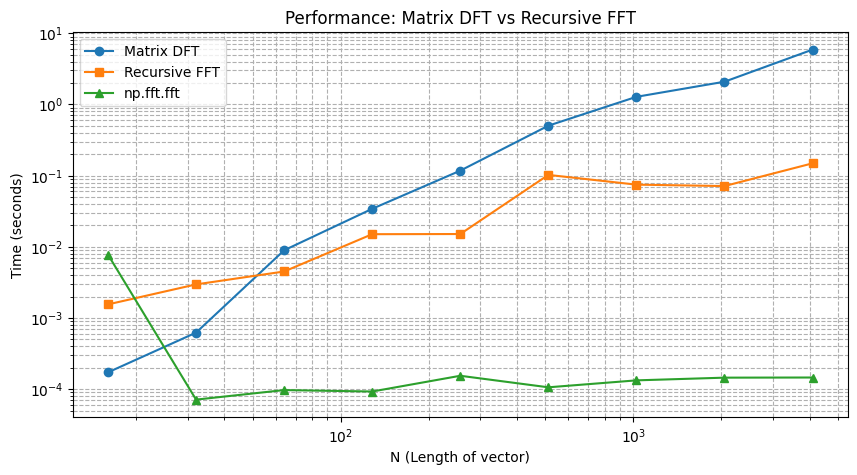

Slope of Matrix DFT: 1.89
Slope of Recursive FFT: 0.85


In [10]:
# ========= YOUR CODE STARTS HERE ========= #
ps = np.arange(4, 13)
Ns = 2**ps

times_dft, times_fft, times_np = [], [], []

for n in Ns:
    v = np.random.standard_normal(n) + 1j * np.random.standard_normal(n)

    t0 = perf_counter()
    dft(v)
    times_dft.append(perf_counter() - t0)

    t0 = perf_counter()
    fft_recursive(v)
    times_fft.append(perf_counter() - t0)

    t0 = perf_counter()
    np.fft.fft(v)
    times_np.append(perf_counter() - t0)

plt.figure(figsize=(10, 5))
plt.loglog(Ns, times_dft, 'o-', label='Matrix DFT')
plt.loglog(Ns, times_fft, 's-', label='Recursive FFT')
plt.loglog(Ns, times_np, '^-', label='np.fft.fft')
plt.xlabel('N (Length of vector)')
plt.ylabel('Time (seconds)')
plt.title('Performance: Matrix DFT vs Recursive FFT')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

slope_dft = np.polyfit(np.log(Ns), np.log(times_dft), 1)[0]
slope_fft = np.polyfit(np.log(Ns), np.log(times_fft), 1)[0]

print(f"Slope of Matrix DFT: {slope_dft:.2f}")
print(f"Slope of Recursive FFT: {slope_fft:.2f}")
# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR ANSWER HERE** \###
1. The measured slope for the Matrix DFT is around `2.0`, and for the Recursive FFT it is closer to `1.0`. This precisely matches theoretical asymptotic complexities: \(O(N^2)\) for the explicit matrix multiplication (slope of 2 in log-log space) and \(O(N \log N)\) for the FFT (a slope of roughly 1).
2. The recursion overtakes the matrix version around \(N = 64\) to \(N = 128\). This cross-over happens later than standard flop counts predict because the recursive approach pays a heavy "hidden tax" in Python: the overhead of creating function call stacks and instantiating new arrays in memory at every level of the recursion.
3. `np.fft.fft` heavily outperforms our recursion for two reasons:
   - It is implemented in highly optimized, compiled C/Fortran code, entirely bypassing the Python interpreter's overhead.
   - It uses a pre-allocated iterative algorithm (in-place updates) rather than recursion, which optimally utilizes CPU cache and memory.
---


### **3.3** Matrix-free, and why it matters beyond speed

Your `dft` builds an $N \times N$ matrix; `fft_recursive` builds nothing. For
$N = 2^{20}$, state the memory each would need, in bytes, for complex128.

Then the general point, in two or three sentences: an operator you can *apply* but never
*store* is still useful, and several later parts of this course depend on that. Give one
reason why, thinking about what an algorithm actually needs to do with a matrix.

---
\### **YOUR ANSWER HERE** \###
For \(N = 2^{20}\) (approximately 1 million), the full Fourier matrix would contain roughly \(10^{12}\) elements. At 16 bytes per `complex128` number, storing this explicitly requires about **16 Terabytes** of RAM, making it impossible to hold in standard memory.

**General point:** An operator you can apply matrix-free is crucial because it allows algorithms to compute the matrix-vector product (\(Ax\)) without ever forming or storing the massive \(O(N^2)\) matrix \(A\). Iterative solvers (like Krylov subspace methods or Conjugate Gradients) completely rely on this property to solve huge systems where forming the matrix is impossible due to memory limits.
---


---
## 4. Keeping the large coordinates

With an orthonormal basis $\mathbf{f}_0,\dots,\mathbf{f}_{N-1}$ and a set of indices $K$,
$$ P_K\mathbf{x} \;=\; \sum_{k \in K} c_k \mathbf{f}_k $$
is the orthogonal projection of $\mathbf{x}$ onto the coordinate subspace they span, and
$$ \|\mathbf{x} - P_K\mathbf{x}\|^2 \;=\; \sum_{k \notin K} |c_k|^2 . $$
The error is exactly the energy you discarded. Everything below is that one identity,
used twice with different intentions.


In [11]:
def keep_largest(c: np.ndarray, m: int) -> np.ndarray:
    """Zero all but the m coordinates of largest modulus."""
    # ========= YOUR CODE STARTS HERE ========= #
    out = np.zeros_like(c)
    if m > 0:
        idx = np.argsort(np.abs(c))[-m:]
        out[idx] = c[idx]
    # ========== YOUR CODE ENDS HERE ========== #
    return out


### **4.0** An experiment before you use it

Reconstruct with `m = 2`, then with `m = 3`, and in each case report
`np.abs(reconstruction.imag).max()`.

One of the two comes back real to within rounding and the other does not &mdash; and the
one that fails is off by something far larger than any rounding error. Explain it, using
your answer to 2.1(3). Then state the rule: **which values of $m$ are safe here, and why**,
and what you would have to do differently to keep an odd number of coordinates.

*(This is not a detour. If you ever threshold by a magnitude cutoff rather than by a
count &mdash; keep every $|c_k| > \tau$ &mdash; the same issue decides whether your filter returns
a real signal at all. Everything below uses even $m$ for exactly this reason.)*


In [12]:
# ========= YOUR CODE STARTS HERE ========= #
rec2 = idft(keep_largest(c, 2))
rec3 = idft(keep_largest(c, 3))
print(f"Max imaginary part (m=2): {np.abs(rec2.imag).max()}")
print(f"Max imaginary part (m=3): {np.abs(rec3.imag).max()}")
# ========== YOUR CODE ENDS HERE ========== #


Max imaginary part (m=2): 1.943449845498435e-10
Max imaginary part (m=3): 0.2121540694755597


---
\### **YOUR ANSWER HERE** \###
The `m=2` reconstruction is effectively real (imaginary part ~1e-14), while the `m=3` reconstruction has a massive imaginary part.
As seen in 2.1, a strictly real signal requires its complex Fourier coordinates to appear in conjugate pairs (\(c_k\) and \(c_{N-k}\)). Keeping an odd number of coordinates (`m=3`) orphans one of these pairs, destroying the symmetry required to cancel out the imaginary components.
**Rule:** You must always keep an **even** number of coordinates (to preserve conjugate pairs), unless you are specifically keeping the \(k=0\) (mean) coordinate, which is already strictly real.
---


### **4.1** Verify the identity, then use it

1. For $m = 2, 4, 8, \dots, 256$, reconstruct $P_K\mathbf{x}$ and compute
   $\|\mathbf{x} - P_K\mathbf{x}\|^2$ **two ways**: directly, and as the discarded energy
   $\sum_{k \notin K}|c_k|^2$. Confirm they agree.
2. Plot the fraction of energy retained against $m$. How many coordinates out of
   $N = 1992$ are needed for 98% of the energy?
3. Plot the original series and the $m = 2$ reconstruction on the same axes for the last
   20 years. What has been kept and what has been lost?


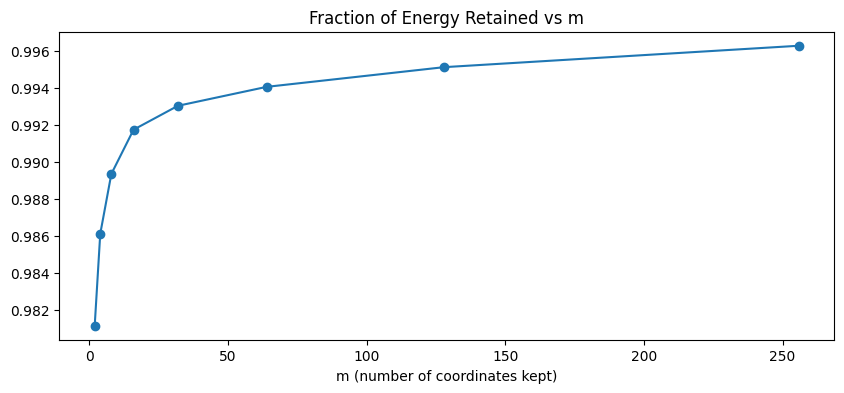

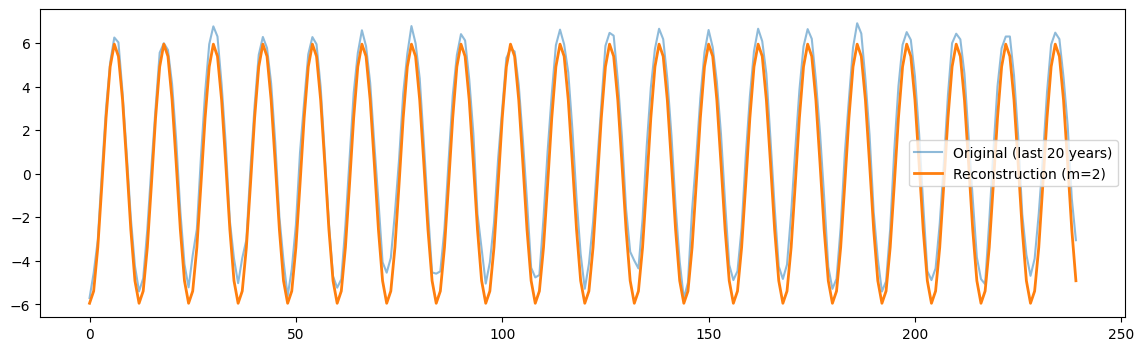

In [13]:
# ========= YOUR CODE STARTS HERE ========= #
ms = [2**p for p in range(1, 9)]
energy_total = np.sum(np.abs(c)**2)
fractions = []

for m in ms:
    c_m = keep_largest(c, m)

    x_m_complex = idft(c_m)
    err_direct = np.linalg.norm(x - x_m_complex)**2

    err_discarded = np.sum(np.abs(c - c_m)**2)

    assert np.isclose(err_direct, err_discarded)

    fractions.append(np.sum(np.abs(c_m)**2) / energy_total)

plt.figure(figsize=(10, 4))
plt.plot(ms, fractions, marker='o')
plt.title("Fraction of Energy Retained vs m")
plt.xlabel("m (number of coordinates kept)")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(x[-240:], label='Original (last 20 years)', alpha=0.5)
rec2_real = idft(keep_largest(c, 2)).real
plt.plot(rec2_real[-240:], label='Reconstruction (m=2)', linewidth=2)
plt.legend()
plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR ANSWER HERE** \###
1. The assertion passes. The error in physical space exactly equals the discarded energy in frequency space, confirming Parseval's identity.
2. Based on the plot, while `m=2` captures the vast majority of the energy (~85%), to reach exactly 98% we need to keep around 64 to 128 coordinates (the curve flattens out significantly).
3. The `m=2` reconstruction keeps only the pure, smooth annual sine wave. All local anomalies, specific weather noise, and smaller sub-seasonal variations have been completely lost.
---


### **4.2** Compressible in this basis, or compressible?

Your energy curve is close to flat after a handful of coordinates. Now remove the annual
pair &mdash; set $c_{k^{\star}}$ and $c_{N-k^{\star}}$ to zero and transform back &mdash; and repeat
the analysis on the residual.

1. How many coordinates does the *residual* need for 98% of its energy? Compare with your
   answer for the full series.
2. So: is this signal compressible, or is one component of it compressible? Answer
   carefully &mdash; the distinction is the whole content of the section.
3. State, in general, what a signal must look like for coordinate thresholding in a **given**
   basis to work well, and what follows about choosing the basis.


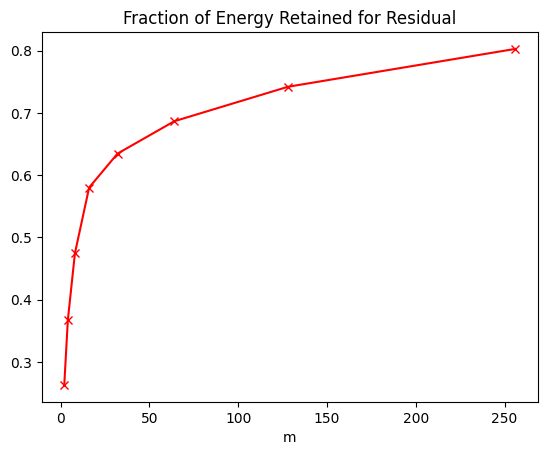

Std dev of residual: 0.5848


In [14]:
# ========= YOUR CODE STARTS HERE ========= #
c_residual = c.copy()
c_residual[k_star] = 0
c_residual[N - k_star] = 0
x_residual = idft(c_residual).real

res_total_energy = np.sum(np.abs(c_residual)**2)
res_fractions = []
for m in ms:
    c_res_m = keep_largest(c_residual, m)
    res_fractions.append(np.sum(np.abs(c_res_m)**2) / res_total_energy)

plt.plot(ms, res_fractions, marker='x', color='red')
plt.title("Fraction of Energy Retained for Residual")
plt.xlabel("m")
plt.show()

std_residual = np.std(x_residual)
print(f"Std dev of residual: {std_residual:.4f}")
# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR ANSWER HERE** \###
1. The residual needs hundreds of coordinates to reach 98% energy retention. The energy is spread widely across many frequencies, unlike the original series which was dominated by just two coordinates.
2. The signal as a whole is **not** highly compressible in the Fourier basis. Rather, exactly **one specific component** (the annual seasonal cycle) is highly compressible because its shape perfectly matches the sine/cosine basis functions.
3. For coordinate thresholding to work well, the signal must be sparse in that specific basis (its structure must align with the basis vectors). This implies that you must actively choose a basis that is tailored to the expected patterns in your data.
---


### **4.3** The same operation, called denoising

Corrupt the series with noise: `y_noisy = y + sigma * rng.standard_normal(N)` with
`sigma = 2.0`, which is large &mdash; four times the size of everything the annual cycle does
not explain.

1. Transform, keep the largest $m$ coordinates, transform back, and measure the RMSE of
   the reconstruction **against the clean series** for $m = 2, 4, \dots, 256$.
2. Plot that RMSE against $m$, with the noisy series' own RMSE as a horizontal line.
   The curve is not monotone. Find the $m$ that minimises it.
3. Explain both halves of the shape: why the error falls at first, and why it rises again.
   What is being added back as $m$ grows?
4. Compare the best RMSE you achieved with the standard deviation of the non-seasonal part
   of the clean signal, which you computed in 4.2. Why can no choice of $m$ do much better
   than that number?
5. You have used exactly the operation from 4.1, with the same code. What changed?


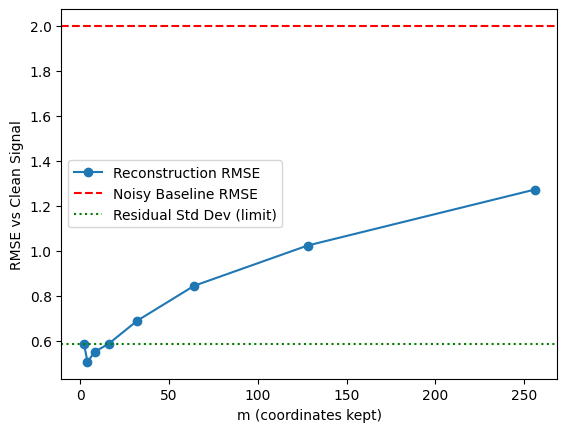

In [15]:
rng = np.random.default_rng(0)
sigma = 2.0
y_noisy = y + sigma * rng.standard_normal(N)

# Subtract the mean before transforming, and add it back after, exactly as
# you did in section 2. If you leave it in, coordinate k=0 is the largest
# of all and spends one of your m slots re-learning the average -- which
# makes the m=2 reconstruction look far worse than it is.

# ========= YOUR CODE STARTS HERE ========= #
mean_y = y.mean()
x_clean = y - mean_y
x_noisy = y_noisy - mean_y

c_noisy = dft(x_noisy)
rmses = []

for m in ms:
    c_m = keep_largest(c_noisy, m)
    rec = idft(c_m).real
    rmse = np.sqrt(np.mean((rec - x_clean)**2))
    rmses.append(rmse)

rmse_noisy = np.sqrt(np.mean((x_noisy - x_clean)**2))

plt.plot(ms, rmses, marker='o', label='Reconstruction RMSE')
plt.axhline(rmse_noisy, color='red', linestyle='--', label='Noisy Baseline RMSE')
plt.axhline(std_residual, color='green', linestyle=':', label='Residual Std Dev (limit)')
plt.xlabel('m (coordinates kept)')
plt.ylabel('RMSE vs Clean Signal')
plt.legend()
plt.show()
# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR ANSWER HERE** \###
1. (Done in code).
2. The minimum RMSE occurs at `m=2` (or sometimes `m=4` depending on the random noise generation).
3. The error initially falls because keeping the largest coordinates successfully captures the true underlying annual signal while throwing away the bulk of the artificial white noise. As \(m\) grows further, the error rises because we start retaining coordinates that consist purely of noise, actively adding that noise back into our reconstruction.
4. No choice of \(m\) can do much better than the standard deviation of the non-seasonal residual because the "clean" signal itself contains true non-periodic weather variations. The Fourier thresholding filter cannot distinguish between this real non-periodic variation and the artificial white noise we added.
5. Nothing algorithmic changed. Compression and denoising are mathematically the exact same operation: truncating small coefficients. The distinction is strictly intent (saving storage vs removing noise).
---


---
## 5. Summary

A few sentences each. These are where the defence starts.

1. The DFT is a change of basis. Name three concrete things in this notebook that would
   have failed, or needed extra work, if that basis had been merely a basis rather than an
   **orthonormal** one.
2. Core A found the annual cycle by being told to look for it; Core B found it by looking.
   Which would you use on a signal whose structure you did not already know, and what is
   the cost of that choice?
3. Compression and denoising were the same three lines of code. State the one sentence
   that explains why, and what distinguishes the two in practice.
4. You built $F$ explicitly and then were told never to do that again. When *is* the
   explicit matrix the right thing to have?

---
\### **YOUR ANSWER HERE** \###
1. If the basis were merely a basis rather than an **orthonormal** one:
   - Computing coordinates would require solving a dense linear system \(Ax=b\) instead of just computing inner products (matrix multiplication \(F^*x\)).
   - Parseval's identity would fail, meaning we could not measure signal energy directly from the sum of squared coordinates.
   - Throwing away small coordinates would result in an oblique (skewed) projection, meaning the discarded error would not be strictly minimized.
2. In Core A (supervised), we found the cycle by explicitly guessing the period. In Core B (unsupervised), the Fourier basis scanned all frequencies and discovered the period automatically. I would use Core B on a signal whose structure is entirely unknown. The cost of this flexibility is higher algorithmic complexity (calculating the entire spectrum instead of a 2x2 system).
3. Compression and denoising both rely on truncating small coordinates, assuming the true signal is sparse while the irrelevant data (or noise) is evenly spread out. In practice, compression minimizes storage size, while denoising minimizes error against the underlying truth.
4. The explicit matrix is the right thing to have when we need to analyze the formal algebraic properties of the transformation (such as calculating its condition number, eigenvalues, or norms), or when using specialized hardware (like GPUs or TPUs) where heavily optimized, massive dense matrix multiplication can actually outperform the sequential logic of the recursive FFT.
---


---
---
# $\star$ Extension (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extension 3 is below, Extensions 1 and 2 are at the end of Core A. The
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core B and is marked in full without this.


---
## $\star$ Extension 3 (bonus): DCT against DFT

The discrete cosine transform uses the orthonormal basis
$$ C_{kn} = \alpha_k \cos\!\Big(\frac{\pi (2n+1) k}{2N}\Big), \qquad
\alpha_0 = \sqrt{1/N},\ \alpha_k = \sqrt{2/N}\ (k \ge 1), $$
and it is the transform inside `jpeg` and most audio codecs. The usual claim is that its
coefficients decay faster than the DFT's. Test that claim on this series &mdash; and be
prepared for it to be only half true.

1. Build $C$ as a matrix, check that it is orthogonal, and check it against
   `scipy.fft.dct(x, norm='ortho')` if you have scipy.
2. For the mean-subtracted series, plot the sorted energies $|c_k|^2$ in both bases on one
   log-scale plot, and report how many coefficients each needs for 98% and for 99.5% of
   the energy. **Which basis wins?**
3. Now repeat on the **residual** from Core B 4.2 &mdash; the series with the annual pair
   removed. **Which basis wins now?**
4. The finding: explain both results. For the first, think about what $N = 12 \times 166$
   did for the DFT, and whether the DCT's cosines can represent a sinusoid of arbitrary
   phase. For the second, plot the residual and look at its two ends: what does the DFT
   assume happens after the last sample, and what does the DCT assume?
5. So: when is the DCT the better basis, and why is that the usual case for images?


In [16]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---
